=== Task 3: Churn Performance Evaluation ===
Accuracy Score: 0.8665

Confusion Matrix:
[[1548   59]
 [ 208  185]]


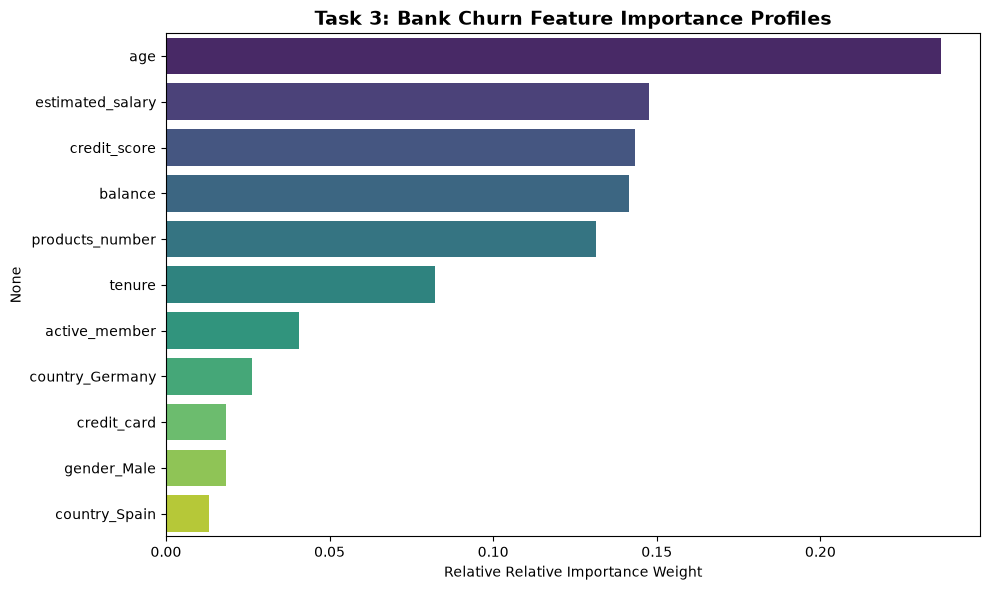

In [6]:
# ==============================================================================
# Task 3: Bank Customer Churn Prediction
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df_churn = pd.read_csv("Bank Customer Churn Prediction.csv")

# 1. Clean and Prepare (Drop index parameters)
X_churn = df_churn.drop(columns=['customer_id', 'churn'])
y_churn = df_churn['churn']

# 2. Encode Categorical Features
X_churn = pd.get_dummies(X_churn, columns=['country', 'gender'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

# 3. Train Classification Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluate Model
y_pred = rf_model.predict(X_test)
print("=== Task 3: Churn Performance Evaluation ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 5. Analyze and Plot Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Task 3: Bank Churn Feature Importance Profiles", fontsize=14, weight='bold')
sns.barplot(x=importances[indices], y=X_churn.columns[indices], palette="viridis", hue=X_churn.columns[indices], legend=False)
plt.xlabel("Relative Relative Importance Weight")
plt.tight_layout()
plt.show()